In [ ]:
# =====================================================================
# CELDA DE COMPATIBILIDAD - Google Colab / Local
# ---------------------------------------------------------------------
# Este notebook funciona IGUAL en dos entornos:
#   * LOCAL  -> usa el venv del proyecto (Python 3.12) y el CSV de data/raw/
#   * COLAB  -> instala las dependencias y descarga el dataset al vuelo
# No hay que tocar nada: la deteccion es automatica.
# =====================================================================
import sys
import subprocess
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    print("Entorno detectado: GOOGLE COLAB -> instalando dependencias...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "pandas", "numpy", "matplotlib", "seaborn",
         "scikit-learn", "imbalanced-learn", "ucimlrepo"],
        check=True,
    )
    # En Colab no existe el repositorio clonado: se arma la estructura minima
    RAIZ = Path("/content/DefenzaGrado")
    (RAIZ / "data" / "raw").mkdir(parents=True, exist_ok=True)
    (RAIZ / "outputs" / "figuras").mkdir(parents=True, exist_ok=True)

    ruta_csv = RAIZ / "data" / "raw" / "desercion_estudiantil.csv"
    if not ruta_csv.exists():
        print("Descargando dataset UCI id=697 ...")
        import pandas as pd
        from ucimlrepo import fetch_ucirepo
        repo = fetch_ucirepo(id=697)
        pd.concat([repo.data.features, repo.data.targets], axis=1).to_csv(
            ruta_csv, index=False, encoding="utf-8"
        )
        print(f"Dataset guardado en {ruta_csv}")
    else:
        print("El dataset ya estaba descargado.")
else:
    print("Entorno detectado: LOCAL -> no se instala nada.")
    # El notebook vive en notebooks/, la raiz del proyecto esta un nivel arriba
    RAIZ = Path.cwd()
    if not (RAIZ / "data").exists():
        RAIZ = RAIZ.parent

# Rutas que usa TODO el notebook a partir de aqui
DIR_DATOS = RAIZ / "data" / "raw"
DIR_FIGURAS = RAIZ / "outputs" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
RUTA_CSV = DIR_DATOS / "desercion_estudiantil.csv"

print(f"\nRaiz del proyecto : {RAIZ}")
print(f"CSV del dataset   : {RUTA_CSV}  (existe: {RUTA_CSV.exists()})")
print(f"Figuras se guardan: {DIR_FIGURAS}")

Entorno detectado: LOCAL -> no se instala nada.

Raiz del proyecto : D:\_Dev\Projects\DefenzaGrado
CSV del dataset   : D:\_Dev\Projects\DefenzaGrado\data\raw\desercion_estudiantil.csv  (existe: True)
Figuras se guardan: D:\_Dev\Projects\DefenzaGrado\outputs\figuras


# Sistema de Alerta Temprana para la Desercion Estudiantil

**Examen de Grado - Ingenieria de Sistemas (UTEPSA)**
**Area:** Inteligencia Artificial | **Caso #01**
**Fecha de defensa:** 13 de agosto de 2026

---

**Objetivo:** construir un clasificador **Random Forest** que identifique, lo antes
posible, a los estudiantes con alto riesgo de desertar durante los primeros
semestres de carrera, para que la universidad pueda intervenir a tiempo.

**Dataset:** *Predicting Student Dropout and Academic Success* -- UCI Machine
Learning Repository, id **697**.
<https://archive.ics.uci.edu/dataset/697/predicting+student+dropout+and+academic+success>

**Metodologia:** CRISP-DM (Cross Industry Standard Process for Data Mining), sus
6 fases estructuran este notebook:

| # | Fase | Que se responde |
|---|------|-----------------|
| 1 | Comprension del Negocio | Que problema resolvemos y como se mide el exito |
| 2 | Comprension de los Datos | Que tenemos, en que estado, que dice el target |
| 3 | Preparacion de los Datos | Como dejamos los datos listos para el modelo |
| 4 | Modelado | Random Forest: entrenamiento y ajuste de hiperparametros |
| 5 | Evaluacion | Metricas, matriz de confusion, ROC, importancia de variables |
| 6 | Implementacion | Como se llevaria esto a produccion en la universidad |

> **Nota sobre este notebook:** la carga de datos (Fases 1-2) esta resuelta y
> verificada. **De la Fase 3 en adelante el codigo esta como `# TODO`**: se
> escribe a mano, porque hay que poder defender cada decision ante el tribunal.

---

## Fase 1 - Comprension del Negocio

### 1.1 El problema

La desercion estudiantil temprana (primeros 4 semestres) le cuesta a la
universidad matriculas perdidas, indicadores de calidad a la baja y capacidad
instalada ociosa; y le cuesta al estudiante tiempo, dinero y, muchas veces, la
carrera. El problema real no es *contar* desertores al final del año: es
**detectarlos mientras todavia se puede hacer algo**.

### 1.2 Objetivo de negocio

Entregar a Bienestar Estudiantil una lista priorizada de estudiantes en riesgo,
al cierre de cada semestre, para activar tutorias, apoyo economico o
acompañamiento academico.

### 1.3 Objetivo de mineria de datos

Entrenar un clasificador **binario** (`desertor` / `no desertor`) sobre las
variables socioeconomicas, academicas y de contexto disponibles al momento de la
matricula y del primer/segundo semestre.

El target original tiene 3 clases (`Dropout`, `Enrolled`, `Graduate`) y **se
simplifica a binario**. Esa simplificacion es una decision a justificar en la
defensa (ver TODO en la Fase 3).

### 1.4 Criterio de exito

En alerta temprana, **el error caro es el falso negativo**: un estudiante que va
a desertar y el sistema no marca es una intervencion que nunca ocurrio. Un falso
positivo, en cambio, solo cuesta una tutoria de mas.

Por eso la metrica que manda es el **recall de la clase `desertor`**, acompañada
de F1 y ROC-AUC para no degradar demasiado la precision. *Accuracy* sola no
sirve: con ~32% de desertores, un modelo que diga "nadie deserta" acierta 68% y
es inutil.

### 1.5 Por que Random Forest

- Maneja mezcla de variables numericas y categoricas sin exigir escalado.
- Robusto a outliers y a relaciones no lineales.
- Entrega **importancia de variables**, que es lo que hace accionable la alerta:
  no basta con decir "este estudiante esta en riesgo", hay que decir por que.
- Menos propenso al sobreajuste que un arbol unico, gracias al bagging.

## Fase 2 - Comprension de los Datos

Se carga el dataset ya descargado por `src/cargar_datos.py` y se revisa su
forma, tipos, nulos y la distribucion del target. Esta fase **si esta resuelta**:
es el punto de partida comun para todo lo que sigue.

Si el CSV no existe todavia, ejecutar antes desde la raiz del proyecto:

```bash
python src/cargar_datos.py
```

In [ ]:
# --- Librerias y configuracion global de graficos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Todas las figuras se exportan a 300 dpi para que entren con calidad en el Word
DPI_EXPORT = 300
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = DPI_EXPORT
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid", palette="deep")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SEMILLA = 42  # reproducibilidad: mismo resultado en cada corrida

print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"matplotlib   {plt.matplotlib.__version__}")
print(f"seaborn      {sns.__version__}")

pandas       3.0.5
numpy        2.5.1
matplotlib   3.11.1
seaborn      0.13.2


In [ ]:
# --- Carga del dataset ---
if not RUTA_CSV.exists():
    raise FileNotFoundError(
        f"No se encontro {RUTA_CSV}.\n"
        "Ejecuta primero desde la raiz del proyecto:  python src/cargar_datos.py"
    )

df = pd.read_csv(RUTA_CSV)

print(f"Forma del dataset (filas, columnas): {df.shape}")
print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

Forma del dataset (filas, columnas): (4424, 37)
Filas    : 4,424
Columnas : 37


In [ ]:
# --- Primeras filas ---
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# --- Tipos de dato, memoria y valores nulos ---
df.info()

print("\n--- Nulos por columna (solo las que tienen) ---")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
if nulos.empty:
    print("No hay valores nulos declarados en el dataset.")
else:
    print(nulos)

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [ ]:
# --- Estadisticos descriptivos de las variables numericas ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [ ]:
# --- Distribucion del target (3 clases originales) ---
conteo = df["Target"].value_counts()
porcentaje = df["Target"].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({"cantidad": conteo, "porcentaje": porcentaje.round(2)})
print(resumen_target)

print("\nLectura rapida:")
print(f"  - Total de estudiantes  : {len(df):,}")
print(f"  - Desertores (Dropout)  : {conteo.get('Dropout', 0):,}"
      f" ({porcentaje.get('Dropout', 0):.1f}%)")
print("  - La clase 'Enrolled' (aun cursando) es el caso ambiguo:")
print("    hay que decidir en la Fase 3 si se agrupa o se descarta.")

          cantidad  porcentaje
Target                        
Graduate      2209       49.93
Dropout       1421       32.12
Enrolled       794       17.95

Lectura rapida:
  - Total de estudiantes  : 4,424
  - Desertores (Dropout)  : 1,421 (32.1%)
  - La clase 'Enrolled' (aun cursando) es el caso ambiguo:
    hay que decidir en la Fase 3 si se agrupa o se descarta.


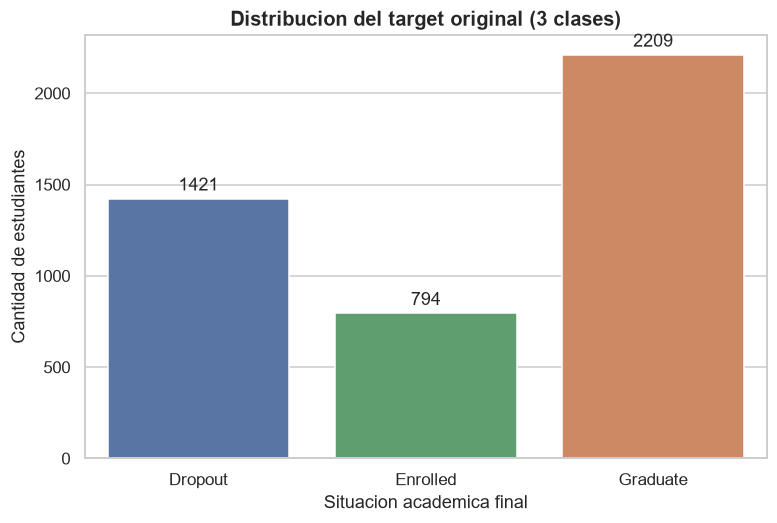

Figura guardada en: D:\_Dev\Projects\DefenzaGrado\outputs\figuras\01_distribucion_target.png


In [ ]:
# --- Figura 1: distribucion del target ---
fig, ax = plt.subplots(figsize=(8, 5))

orden = ["Dropout", "Enrolled", "Graduate"]
sns.countplot(data=df, x="Target", order=orden, hue="Target",
              legend=False, ax=ax)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d", padding=3)

ax.set_title("Distribucion del target original (3 clases)", fontsize=13, weight="bold")
ax.set_xlabel("Situacion academica final")
ax.set_ylabel("Cantidad de estudiantes")

plt.savefig(DIR_FIGURAS / "01_distribucion_target.png", dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {DIR_FIGURAS / '01_distribucion_target.png'}")

### 2.1 Exploracion mas profunda (a completar)

Lo anterior es el reconocimiento minimo. El analisis exploratorio que sostiene
las decisiones de la Fase 3 todavia hay que hacerlo.

> Guia paso a paso de que se espera en cada TODO de abajo y por que le importa
> a la defensa (sin codigo resuelto): ver `08-Defensa-Grado/Guia-Fase2-EDA.md`
> en el vault.

In [ ]:
# TODO: separar las columnas en dos listas segun su naturaleza real, no segun el dtype.
#       Ojo: varias categoricas vienen codificadas como enteros (por ejemplo
#       'Marital Status', 'Application mode', 'Course', "Mother's qualification").
#       Tratarlas como numericas seria un error conceptual - hay que justificarlo.
#       Sugerencia: crear COLUMNAS_CATEGORICAS y COLUMNAS_NUMERICAS a mano,
#       apoyandose en la ficha oficial del dataset en UCI.

# TODO: revisar la cardinalidad de cada categorica (df[col].nunique()) porque de
#       eso depende si el one-hot encoding de la Fase 3 es viable o explota en columnas.

# TODO: graficar la distribucion de las variables numericas clave
#       ('Age at enrollment', 'Admission grade', 'Curricular units 1st sem (approved)',
#        'Curricular units 2nd sem (approved)', 'Curricular units 1st/2nd sem (grade)')
#       con histogramas o boxplots, y detectar outliers y asimetrias.
#       Guardar la figura como outputs/figuras/02_distribucion_numericas.png a 300 dpi.

# TODO: comparar esas mismas variables ENTRE desertores y no desertores
#       (boxplot con hue=Target). Aqui es donde aparece la senal del modelo:
#       hay que poder contar en la defensa que diferencia a un desertor.

# TODO: matriz de correlacion de las numericas (heatmap) para detectar
#       variables redundantes -- por ejemplo, 'enrolled' vs 'approved' de cada
#       semestre suelen estar muy correlacionadas.
#       Guardar como outputs/figuras/03_matriz_correlacion.png a 300 dpi.

# TODO: revisar si hay filas duplicadas (df.duplicated().sum()) y decidir que hacer.

# TODO: verificar valores imposibles o centinela: notas en 0 que en realidad
#       significan "sin evaluacion", edades fuera de rango, etc.

In [ ]:
# 1. Definicion de columnas segun su naturaleza real
COLUMNAS_CATEGORICAS = [
    'Marital Status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

COLUMNAS_BINARIAS = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International'
]

COLUMNAS_NUMERICAS = [
    'Application order', 'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment', 'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
    'Inflation rate', 'GDP'
]

print(f"Categoricas : {len(COLUMNAS_CATEGORICAS)}")
print(f"Binarias    : {len(COLUMNAS_BINARIAS)}")
print(f"Numericas   : {len(COLUMNAS_NUMERICAS)}")
print(f"Total       : {len(COLUMNAS_CATEGORICAS) + len(COLUMNAS_BINARIAS) + len(COLUMNAS_NUMERICAS)} (de 36 features + 1 target)")

In [ ]:
print("--- Cardinalidad de variables categoricas ---")
# Iteramos sobre la lista de categoricas para ver el impacto potencial en el encoding
for col in COLUMNAS_CATEGORICAS:
    n_unicos = df[col].nunique()
    print(f"{col:25}: {n_unicos} valores unicos")

--- Cardinalidad de variables categoricas ---
Marital Status           : 6 valores unicos
Application mode         : 18 valores unicos
Course                   : 17 valores unicos
Previous qualification   : 17 valores unicos
Nacionality              : 21 valores unicos
Mother's qualification   : 29 valores unicos
Father's qualification   : 34 valores unicos
Mother's occupation      : 32 valores unicos
Father's occupation      : 46 valores unicos


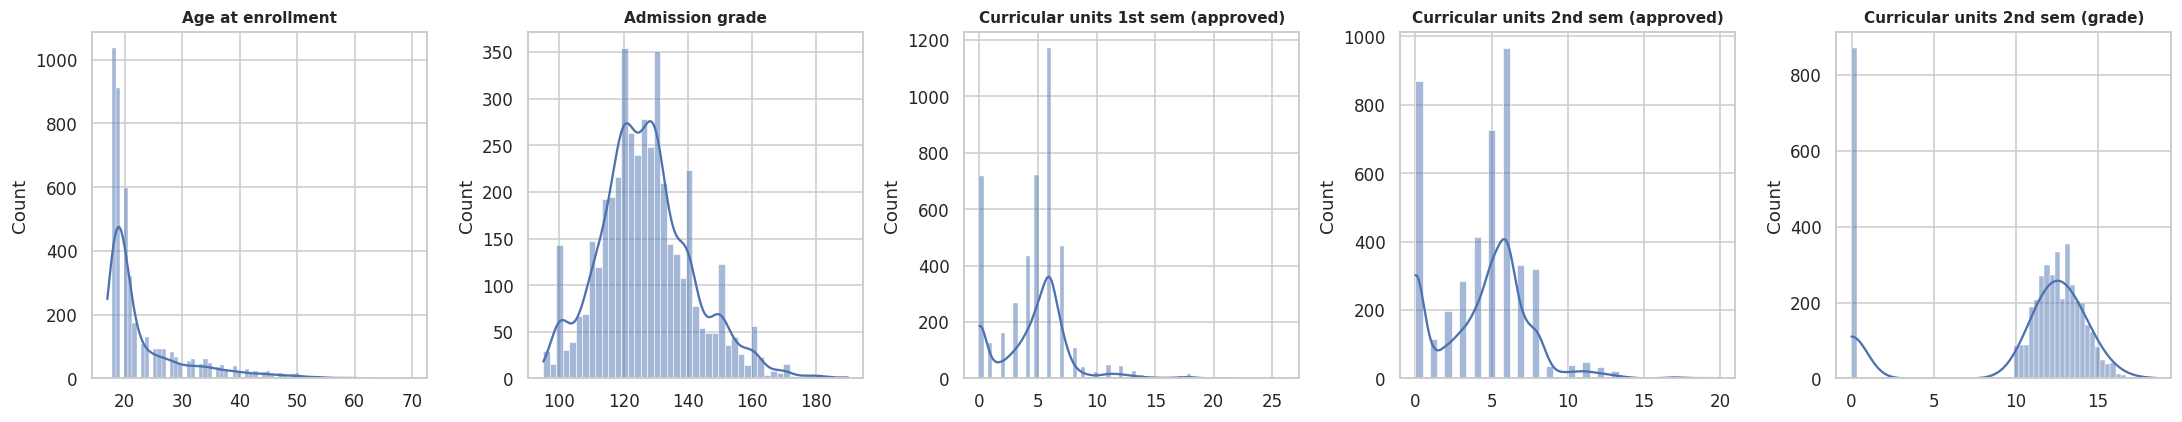

Figura guardada en: /content/DefenzaGrado/outputs/figuras/02_distribucion_numericas.png


In [11]:
columnas_clave = [
    'Age at enrollment', 'Admission grade',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, columnas_clave):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('')

# La mayoria de los estudiantes tiene 18-22 anos, pero la distribucion es
# asimetrica a la derecha (media 23.3 > mediana 20): hay una cola de
# estudiantes no tradicionales (30+) que arrastra la media hacia arriba.
# Esa cola es poblacion de riesgo -- Age at enrollment correlaciona con
# desercion (ver TODO de correlacion mas abajo).
plt.tight_layout()
# Guardamos usando la ruta definida previamente en el notebook
ruta_fig_02 = DIR_FIGURAS / '02_distribucion_numericas.png'
plt.savefig(ruta_fig_02, dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {ruta_fig_02}")

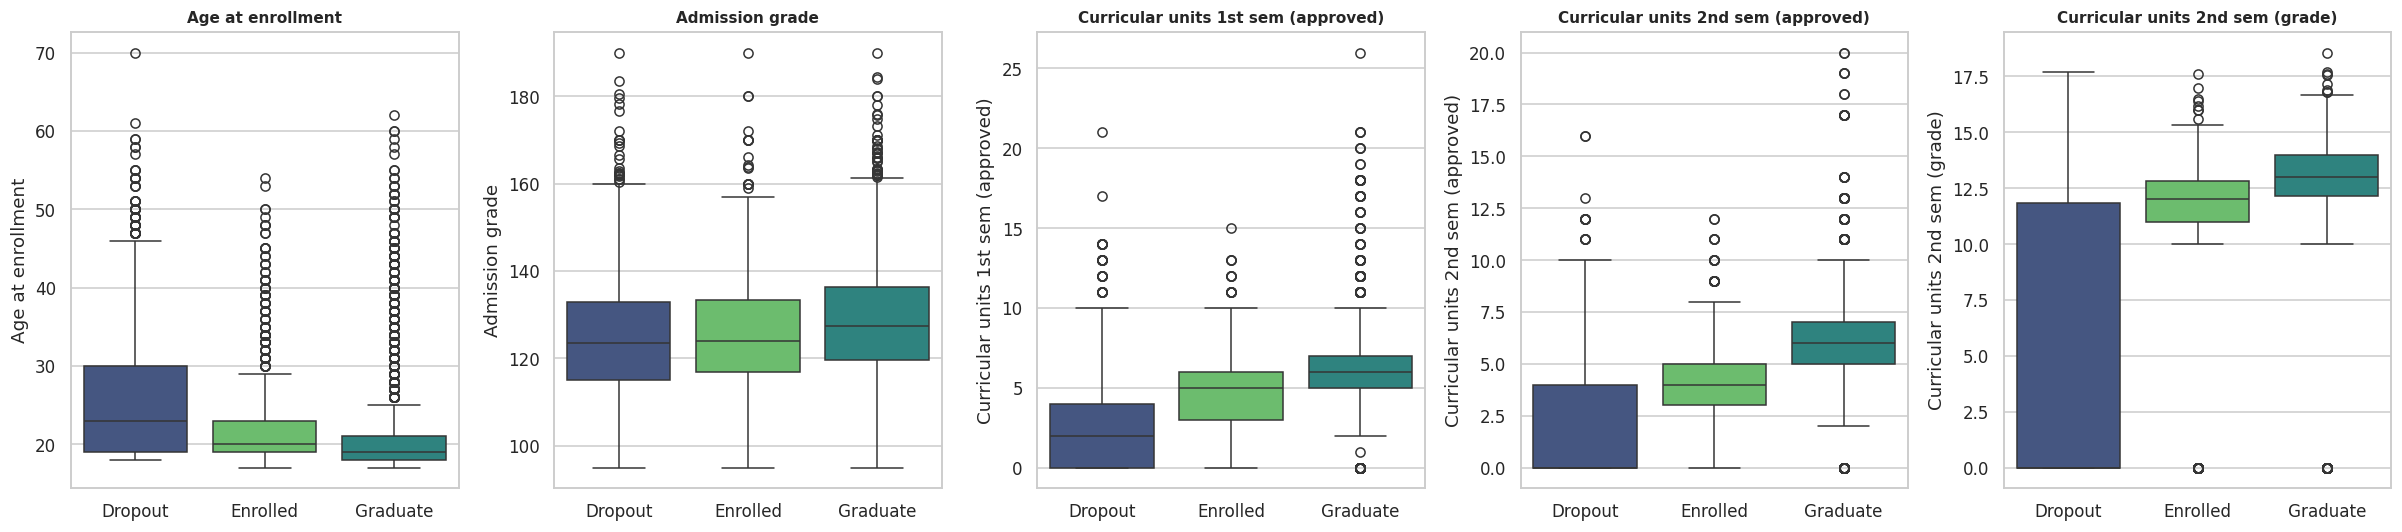

Figura guardada en: /content/DefenzaGrado/outputs/figuras/03_comparacion_por_clase.png


In [12]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# El orden es fundamental para ver la progresion academica
orden_target = ['Dropout', 'Enrolled', 'Graduate']

for ax, col in zip(axes, columnas_clave):
    sns.boxplot(data=df, x='Target', y=col, order=orden_target, palette='viridis', hue='Target', legend=False, ax=ax)
    ax.set_title(col, fontsize=10, weight='bold')
    ax.set_xlabel('')

plt.tight_layout()
# Guardamos la figura 03
ruta_fig_03 = DIR_FIGURAS / '03_comparacion_por_clase.png'
plt.savefig(ruta_fig_03, dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {ruta_fig_03}")

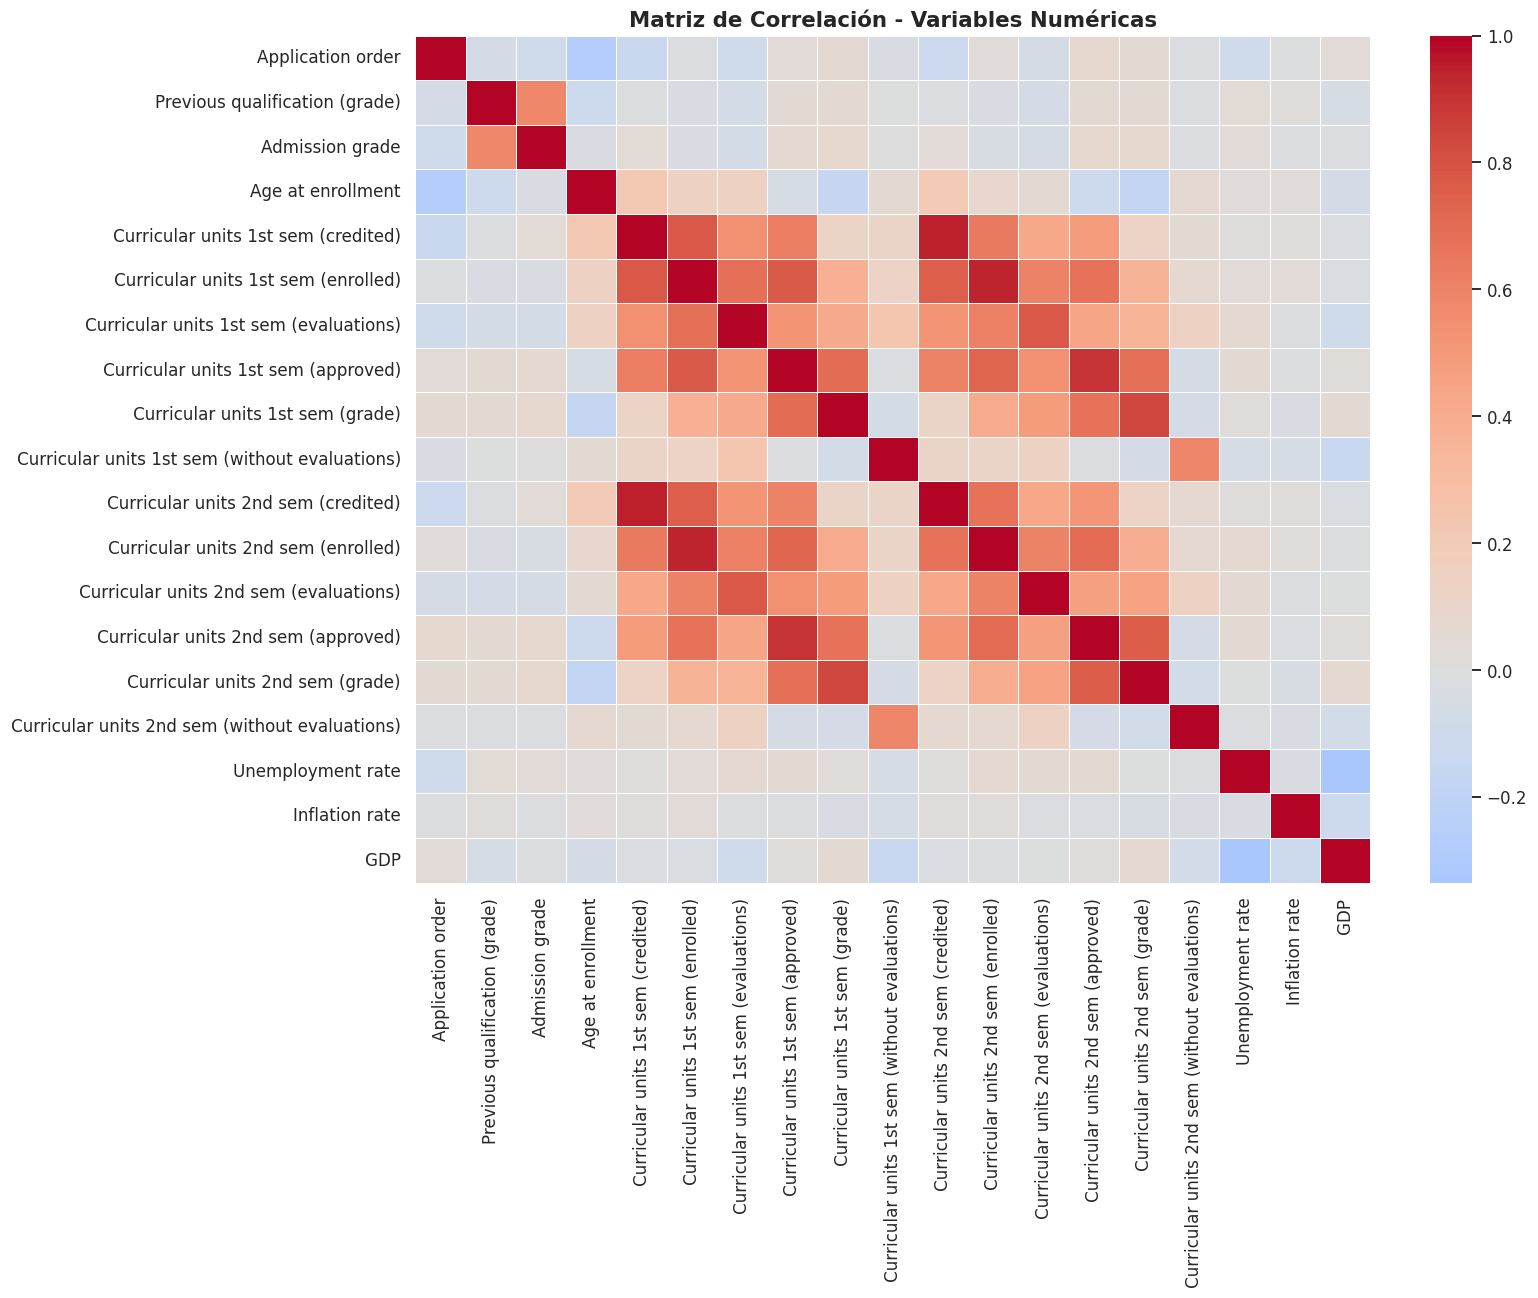

--- Posibles redundancias (Correlación > 0.8) ---
                                    Var1                                 Var2      Corr
86   Curricular units 1st sem (credited)  Curricular units 2nd sem (credited)  0.944811
194  Curricular units 2nd sem (credited)  Curricular units 1st sem (credited)  0.944811
214  Curricular units 2nd sem (enrolled)  Curricular units 1st sem (enrolled)  0.942627
106  Curricular units 1st sem (enrolled)  Curricular units 2nd sem (enrolled)  0.942627
254  Curricular units 2nd sem (approved)  Curricular units 1st sem (approved)  0.904002
146  Curricular units 1st sem (approved)  Curricular units 2nd sem (approved)  0.904002
166     Curricular units 1st sem (grade)     Curricular units 2nd sem (grade)  0.837170
274     Curricular units 2nd sem (grade)     Curricular units 1st sem (grade)  0.837170


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la correlación solo para las columnas numéricas
corr_matrix = df[COLUMNAS_NUMERICAS].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)

plt.title("Matriz de Correlación - Variables Numéricas", fontsize=14, weight='bold')

# Guardamos la figura
ruta_fig_04 = DIR_FIGURAS / '04_matriz_correlacion.png'
plt.savefig(ruta_fig_04, dpi=DPI_EXPORT)
plt.show()

# Identificar correlaciones altas (> 0.8)
print("--- Posibles redundancias (Correlación > 0.8) ---")
high_corr = corr_matrix.stack().reset_index()
high_corr.columns = ['Var1', 'Var2', 'Corr']
high_corr = high_corr[(high_corr['Corr'] > 0.8) & (high_corr['Var1'] != high_corr['Var2'])]
print(high_corr.sort_values(by='Corr', ascending=False))

In [14]:
# --- Chequeos finales de Calidad de Datos ---

# 1. Filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# 2. Verificar valores en 0 en columnas clave (Notas y Unidades Aprobadas)
# En este dataset, un 0 puede ser una nota real o la ausencia de evaluaciones.
columnas_notas = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']

print("\n--- Analisis de valores en cero ---")
for col in columnas_notas:
    conteo_ceros = (df[col] == 0).sum()
    porcentaje_ceros = (conteo_ceros / len(df)) * 100
    print(f"{col:35}: {conteo_ceros} ceros ({porcentaje_ceros:.2f}%)")

# 3. Edad al matricularse
print(f"\nRango de edad: {df['Age at enrollment'].min()} a {df['Age at enrollment'].max()} años")

Filas duplicadas: 0

--- Analisis de valores en cero ---
Curricular units 1st sem (grade)   : 718 ceros (16.23%)
Curricular units 2nd sem (grade)   : 870 ceros (19.67%)

Rango de edad: 17 a 70 años


## Fase 3 - Preparacion de los Datos

Aqui se transforma el dataset crudo en la matriz `X` y el vector `y` que consume
el modelo. Cada decision de esta fase es defendible o no: no hay una respuesta
"correcta" universal, hay una respuesta **justificada** para este caso.

> A partir de aqui, todo el codigo esta como `# TODO`.

In [ ]:
# ============ 3.1 Definicion del target binario ============

# DECISION YA TOMADA (validada con los datos reales, ver 08-Defensa-Grado/
# Caso-IA-Desercion-Estudiantil.md): la clase 'Enrolled' (794 estudiantes) NO
# tiene desenlace confirmado todavia -- no se puede usar para entrenar ni para
# evaluar el modelo, porque no hay forma de saber si el numero real de aciertos
# es correcto. Se excluye del entrenamiento y se guarda aparte para usarla en la
# Fase 6 como poblacion de inferencia en vivo (la demo real: puntuar estudiantes
# actualmente matriculados, que es el caso de uso real del sistema).

# TODO: separar el dataframe en dos:
#         df_entrenamiento -> solo filas con Target en {'Dropout', 'Graduate'}
#         df_enrolled       -> solo filas con Target == 'Enrolled' (para la Fase 6)
#       Verificar que df_entrenamiento tenga 3.630 filas (1.421 Dropout + 2.209
#       Graduate) y df_enrolled tenga 794.

# TODO: sobre df_entrenamiento, crear la columna 'desertor' con 1 = Dropout,
#       0 = Graduate. Verificar el balance con value_counts() -- deberia dar
#       un ratio cercano a 1,55:1 (Graduate:Dropout), menos desbalanceado que
#       si se hubiera incluido Enrolled como clase negativa.

# TODO: separar X (variables predictoras) e y (target binario) A PARTIR DE
#       df_entrenamiento unicamente, eliminando de X la columna 'Target' original
#       para no filtrar la respuesta (data leakage: el error mas caro y el mas
#       facil de cometer). df_enrolled se deja intacto, sin columna 'desertor'
#       (no la tiene), para usarlo en la Fase 6.

In [15]:
# 1. Separar el dataframe segun el estado del target
df_entrenamiento = df[df['Target'].isin(['Dropout', 'Graduate'])].copy()
df_enrolled = df[df['Target'] == 'Enrolled'].copy()

# 2. Crear la variable objetivo binaria 'desertor'
# 1 = Dropout (clase positiva), 0 = Graduate (clase negativa)
df_entrenamiento['desertor'] = df_entrenamiento['Target'].map({'Dropout': 1, 'Graduate': 0})

# 3. Separar X e y para el entrenamiento
X = df_entrenamiento.drop(columns=['Target', 'desertor'])
y = df_entrenamiento['desertor']

print(f"Filas para entrenamiento/prueba: {df_entrenamiento.shape[0]}")
print(f"Filas para inferencia futura (Enrolled): {df_enrolled.shape[0]}")
print("\nDistribucion de la nueva variable 'desertor':")
print(y.value_counts(normalize=True).map(lambda n: f'{n:.2%}') )

Filas para entrenamiento/prueba: 3630
Filas para inferencia futura (Enrolled): 794

Distribucion de la nueva variable 'desertor':
desertor
0    60.85%
1    39.15%
Name: proportion, dtype: object


In [ ]:
# ============ 3.2 Valores nulos ============

# TODO: imputar nulos -- decidir media / mediana / moda segun el TIPO de variable
#       y justificar la eleccion:
#         * numericas simetricas  -> media
#         * numericas con outliers o asimetria -> mediana (mas robusta)
#         * categoricas -> moda, o una categoria explicita "Desconocido"
#       Este dataset no reporta nulos declarados: si se confirma que no hay,
#       DEJARLO ESCRITO igual (que no haya nulos tambien es un hallazgo que
#       el tribunal puede preguntar).

# TODO: si en la Fase 2 se detectaron valores centinela (ceros que significan
#       "sin dato"), decidir si se convierten a NaN antes de imputar.

# TODO: usar SimpleImputer dentro de un Pipeline en vez de imputar sobre el df
#       completo. Motivo: si se imputa con la media de TODO el dataset, la media
#       del set de prueba se filtra al entrenamiento (data leakage sutil).

In [16]:
from sklearn.impute import SimpleImputer

# Verificacion de nulos en el conjunto de entrenamiento
nulos_entrenamiento = X.isnull().sum().sum()

if nulos_entrenamiento == 0:
    print("No se detectaron valores nulos (NaN) en las variables predictoras.")
    print("Decision: No se requiere imputacion, pero se mantiene la logica de SimpleImputer en el pipeline final por robustez.")
else:
    print(f"Se detectaron {nulos_entrenamiento} valores nulos.")

# Nota para la defensa:
# Aunque no hay NaNs, los ceros en 'Curricular units 2nd sem (grade)'
# se consideran informacion valiosa del desempeño y no errores de carga.

No se detectaron valores nulos (NaN) en las variables predictoras.
Decision: No se requiere imputacion, pero se mantiene la logica de SimpleImputer en el pipeline final por robustez.


In [ ]:
# ============ 3.3 Codificacion de variables categoricas ============

# TODO: elegir la estrategia de encoding y justificarla:
#         * One-Hot (pd.get_dummies / OneHotEncoder): correcto cuando NO hay orden
#           entre las categorias (ej. 'Course', 'Marital Status', 'Nacionality').
#           Costo: agrega muchas columnas si la cardinalidad es alta.
#         * Label / Ordinal encoding: solo valido cuando SI hay orden real
#           (ej. niveles de cualificacion de los padres, si se asume jerarquia).
#       Advertencia para la defensa: aplicar label encoding a una categorica sin
#       orden le inventa una relacion de magnitud al modelo (Course 5 > Course 2).
#       Random Forest lo tolera mejor que un modelo lineal, pero sigue siendo
#       una decision que hay que poder explicar.

# TODO: las binarias ya codificadas 0/1 ('Displaced', 'Debtor', 'Gender',
#       'Scholarship holder', 'International', 'Tuition fees up to date', ...)
#       no necesitan transformacion: verificarlo y dejarlo dicho.

# TODO: aplicar el encoding con ColumnTransformer para que quede dentro del
#       Pipeline y sea reproducible en produccion (Fase 6).

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Definimos el transformador de columnas
# 'remainder=passthrough' asegura que las columnas que no transformamos (numéricas y binarias) se mantengan
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COLUMNAS_CATEGORICAS)
    ],
    remainder='passthrough'
)

# Nota para la defensa:
# Usamos OneHotEncoder para variables nominales para evitar sesgos de magnitud.
# handle_unknown='ignore' es vital para que el modelo no falle si en el futuro
# aparece una categoria nueva no vista en el entrenamiento.

print("Configuracion del preprocesador lista.")
print(f"Columnas a codificar: {len(COLUMNAS_CATEGORICAS)}")

Configuracion del preprocesador lista.
Columnas a codificar: 9


In [ ]:
# ============ 3.4 Escalado ============
#
# ===== POR QUE =====
# DECISION: no se escala. Y saber por que NO se hace algo vale tanto como hacerlo.
#
# Random Forest toma decisiones del tipo "¿es esta variable <= umbral?". Le da
# exactamente igual que una variable vaya de 0 a 20 y otra de 0 a 200: el corte
# se busca en la escala propia de cada una. Escalar no cambiaria ni una sola
# particion del arbol.
#
# El escalado SI seria obligatorio si comparasemos contra modelos basados en
# distancia o en magnitud de coeficientes (KNN, SVM, regresion logistica).
# El modelo alternativo que se compara en 4.4 es XGBoost, que tambien parte por
# umbral -> tampoco lo necesita. Por eso el pipeline no lleva StandardScaler.

print("Sin escalado: Random Forest y XGBoost parten por umbral, la escala es irrelevante.")
print("Rangos muy distintos que conviven sin problema:")
for c in ['Admission grade', 'Curricular units 2nd sem (grade)', 'Age at enrollment', 'GDP']:
    print(f"  {c:38} {X[c].min():8.2f} .. {X[c].max():8.2f}")

In [ ]:
# ============ 3.5 Division entrenamiento / prueba ============
#
# ===== POR QUE =====
# stratify=y es OBLIGATORIO con clases desbalanceadas. Sin el, un split al azar
# puede dejar 35% de desertores en train y 43% en test; entonces las metricas de
# test no miden al modelo, miden la suerte del sorteo.
#
# test_size=0.2 -> 726 filas de prueba, de las cuales ~284 son desertores reales.
# Ese numero importa: es la base sobre la que se traduce el criterio de exito a
# cantidades concretas (Recall>=80% -> detectar >=228 de esos 284).
#
# REGLA QUE NO SE ROMPE: el conjunto de prueba no se toca hasta la Fase 5.
# Todo el ajuste de hiperparametros se hace por validacion cruzada DENTRO del
# entrenamiento. Mirar test para elegir parametros es contaminarlo, y las
# metricas finales dejarian de ser una estimacion honesta.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)

print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")
print(f"\n{'':12} {'% desertor':>12} {'n desertor':>12}")
for nombre, yy in [('completo', y), ('train', y_train), ('test', y_test)]:
    print(f"{nombre:12} {yy.mean():>11.2%} {int(yy.sum()):>12}")

print(f"\nDesertores reales en test: {int(y_test.sum())}")
print(f"  Recall >= 80% exige detectar >= {int(np.ceil(0.8 * y_test.sum()))} de ellos "
      f"-> maximo {int(y_test.sum()) - int(np.ceil(0.8 * y_test.sum()))} Falsos Negativos")

In [ ]:
# ============ 3.6 Manejo del desbalanceo: class_weight vs SMOTE ============
#
# ===== POR QUE =====
# Dos estrategias posibles, y en vez de opinar se MIDEN las dos:
#
# (a) class_weight='balanced': no toca los datos, cambia la funcion de costo.
#     Pondera cada clase inversamente a su frecuencia, asi equivocarse en un
#     desertor penaliza mas. Formula: peso = N / (n_clases * n_de_esa_clase).
#     Sin datos sinteticos, sin riesgo de fuga, un solo parametro.
#
# (b) SMOTE: genera ejemplos sinteticos de la minoritaria interpolando vecinos.
#     Puede subir el recall, pero INVENTA observaciones que no existieron.
#
# EL ERROR QUE HAY QUE SABER EXPLICAR (blanco tipico de tribunal): aplicar SMOTE
# ANTES del split. Si se hace, un punto sintetico derivado de un estudiante que
# quedara en test entra al entrenamiento -> se evalua contra informacion ya
# vista y las metricas salen infladas. Por eso SMOTE va DENTRO del Pipeline de
# imblearn, que lo aplica solo al fold de entrenamiento en cada iteracion del CV.

from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
print("class_weight='balanced' calcula:")
print(f"  Graduate (0): {pesos[0]:.3f}")
print(f"  Dropout  (1): {pesos[1]:.3f}")
print(f"  -> equivocarse en un desertor pesa {pesos[1]/pesos[0]:.2f}x mas durante el entrenamiento")

n_min, n_may = int(y_train.sum()), int((y_train == 0).sum())
print(f"\nSi en cambio se igualaran las clases con SMOTE:")
print(f"  habria que generar {n_may - n_min} estudiantes sinteticos")
print(f"  el set de entrenamiento pasaria de {len(y_train)} a {n_may * 2} filas")

In [ ]:
# --- Comparacion MEDIDA: class_weight vs SMOTE (ambas por validacion cruzada) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline as PipelineSk
from imblearn.pipeline import Pipeline as PipelineImb
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
METRICAS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


def evaluar(pipeline, nombre, X_=None, y_=None):
    """Corre CV y devuelve una fila con media +/- desviacion de cada metrica."""
    X_ = X_train if X_ is None else X_
    y_ = y_train if y_ is None else y_
    res = cross_validate(pipeline, X_, y_, cv=cv, scoring=METRICAS, n_jobs=-1)
    fila = {'estrategia': nombre}
    for m in METRICAS:
        fila[m] = res[f'test_{m}'].mean()
        fila[f'{m}_std'] = res[f'test_{m}'].std()
    return fila


rf_base = dict(n_estimators=200, random_state=SEMILLA, n_jobs=-1)

pipe_weight = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(class_weight='balanced', **rf_base)),
])

pipe_smote = PipelineImb([
    ('prep', preprocesador),
    ('smote', SMOTE(random_state=SEMILLA)),   # solo se aplica al fold de train
    ('clf', RandomForestClassifier(**rf_base)),
])

pipe_nada = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(**rf_base)),
])

filas = [
    evaluar(pipe_nada, 'sin tratamiento'),
    evaluar(pipe_weight, "class_weight='balanced'"),
    evaluar(pipe_smote, 'SMOTE'),
]
comparativa_desbalanceo = pd.DataFrame(filas).set_index('estrategia')
print("Validacion cruzada 5-fold sobre el conjunto de ENTRENAMIENTO:\n")
print(comparativa_desbalanceo[METRICAS].round(4).to_string())
print("\nDesviacion estandar del recall entre pliegues (estabilidad):")
print(comparativa_desbalanceo['recall_std'].round(4).to_string())

In [ ]:
# ============ 3.7 One-hot vs enteros nativos ============
#
# ===== POR QUE =====
# Random Forest tolera categoricas como enteros: cada arbol solo corta por
# umbral, no asume que 9500 > 33 signifique algo real en magnitud. Entonces el
# one-hot de 3.3 (que infla a ~220 columnas para 3.630 filas) es una decision
# discutible, no una obligacion.
#
# En vez de defenderla con teoria, se mide: mismo modelo, mismo CV, mismos folds,
# cambiando solo el preprocesamiento. Sea cual sea el resultado, la respuesta al
# tribunal deja de ser "porque es la buena practica" y pasa a ser un numero.

# El one-hot no esta cuantificado en la celda 3.3, se calcula aca:
n_cols_onehot = len(preprocesador.fit(X).get_feature_names_out())
print(f"Columnas tras one-hot: {n_cols_onehot} (originales: {X.shape[1]})")

pipe_onehot = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(class_weight='balanced', **rf_base)),
])

# 'passthrough' = sin transformar nada: las categoricas entran como enteros
pipe_nativo = PipelineSk([
    ('clf', RandomForestClassifier(class_weight='balanced', **rf_base)),
])

comparativa_encoding = pd.DataFrame([
    evaluar(pipe_onehot, f'one-hot ({n_cols_onehot} columnas)'),
    evaluar(pipe_nativo, f'enteros nativos ({X.shape[1]} columnas)'),
]).set_index('estrategia')

print("Validacion cruzada 5-fold, unica diferencia = el encoding:\n")
print(comparativa_encoding[METRICAS].round(4).to_string())

dif_recall = (comparativa_encoding.loc[f'one-hot ({n_cols_onehot} columnas)', 'recall']
              - comparativa_encoding.loc[f'enteros nativos ({X.shape[1]} columnas)', 'recall'])
print(f"\nDiferencia de recall (one-hot - nativo): {dif_recall:+.4f}")
print("Si la diferencia es despreciable, el argumento defendible es que el one-hot")
print("se mantiene por correccion conceptual (no imponer orden falso), no por ganancia.")

## Fase 4 - Modelado

Random Forest es el modelo exigido por el caso. Se entrena una linea base, se
valida con `StratifiedKFold` y recien despues se ajustan los hiperparametros.

In [ ]:
# ============ 4.1 Linea base y piso absoluto ============
#
# ===== POR QUE =====
# Dos puntos de comparacion, sin los cuales cualquier metrica final no significa nada:
#
# 1. DummyClassifier('most_frequent'): predice siempre "no desertor". Es el piso
#    absoluto. Su accuracy va a ser ~61% -- alta y completamente inutil, porque su
#    recall es 0: no detecta ni un solo desertor. Es LA demostracion de por que
#    accuracy es una metrica trampa en este problema y por que se prioriza recall.
#
# 2. Random Forest con parametros por defecto: la linea base real. Si el modelo
#    ajustado de 4.3 no le gana a esto, todo el ajuste fue tiempo perdido.

from sklearn.dummy import DummyClassifier

pipe_dummy = PipelineSk([
    ('clf', DummyClassifier(strategy='most_frequent')),
])

pipe_rf_default = PipelineSk([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(random_state=SEMILLA, n_jobs=-1)),
])

comparativa_base = pd.DataFrame([
    evaluar(pipe_dummy, 'Dummy (siempre "no desertor")'),
    evaluar(pipe_rf_default, 'RF por defecto'),
    evaluar(pipe_weight, "RF + class_weight='balanced'"),
]).set_index('estrategia')

print(comparativa_base[METRICAS].round(4).to_string())
print("\nLeer la fila del Dummy: accuracy alta, recall 0. Ese contraste es el")
print("argumento de por que el criterio de exito del caso se fija en Recall.")

In [ ]:
# ============ 4.2 Validacion cruzada estratificada ============
#
# ===== POR QUE =====
# StratifiedKFold conserva la proporcion de desertores en CADA pliegue. Con
# KFold comun, un pliegue podria quedar con 30% de desertores y otro con 45%:
# la varianza reportada mediria el desbalance del sorteo, no la estabilidad del
# modelo.
#
# k=5 es el valor que pide el caso. Con 2.904 filas de entrenamiento da pliegues
# de ~581 filas -- suficiente para que cada metrica sea estable.
#
# Se reporta media +/- desviacion, no solo media: un modelo con recall 0.82+-0.02
# es confiable; uno con 0.82+-0.11 es una moneda al aire que promedio bien.

for i, (idx_tr, idx_va) in enumerate(cv.split(X_train, y_train), 1):
    y_va = y_train.iloc[idx_va]
    print(f"Pliegue {i}: {len(idx_va)} filas de validacion | "
          f"desertores {int(y_va.sum())} ({y_va.mean():.2%}) | "
          f"entrenamiento {len(idx_tr)}")

print("\nMetricas del modelo con class_weight (media +/- desviacion entre pliegues):")
fila = comparativa_base.loc["RF + class_weight='balanced'"]
for m in METRICAS:
    print(f"  {m:10} {fila[m]:.4f} +/- {fila[f'{m}_std']:.4f}")

In [ ]:
# ============ 4.3 Ajuste de hiperparametros ============
#
# ===== POR QUE =====
# Espacio de busqueda EXACTO del enunciado. Que controla cada uno:
#   - n_estimators      : cuantos arboles votan. Mas = mas estable y mas lento.
#                         NO causa sobreajuste (es lo contrario a lo intuitivo:
#                         promediar mas arboles reduce varianza).
#   - max_depth         : cuanto crece cada arbol. Mas profundo = mas memoriza.
#   - min_samples_split : minimo de muestras para partir un nodo.
#   - min_samples_leaf  : minimo de muestras en una hoja.
#     Los dos ultimos son frenos: al subirlos, el arbol generaliza mas.
#
# GridSearchCV vs RandomizedSearchCV: se calcula abajo el tamano del grid
# completo. Ese numero (multiplicado por 5 folds) es el argumento para elegir
# busqueda aleatoria -- Bergstra & Bengio (2012) mostraron que muestrear al azar
# encuentra configuraciones equivalentes con una fraccion del costo, porque
# pocos hiperparametros dominan el resultado.
#
# scoring='recall', NO 'accuracy': la busqueda tiene que optimizar la misma
# metrica que declaramos como criterio de exito en la Fase 1. Optimizar accuracy
# aqui y despues reportar recall seria incoherente.

from sklearn.model_selection import RandomizedSearchCV

espacio = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_depth': [5, 8, 10, 12, 15, 20, None],
    'clf__min_samples_split': [2, 4, 6, 8, 10],
    'clf__min_samples_leaf': [1, 2, 3, 4, 5],
}

combinaciones = np.prod([len(v) for v in espacio.values()])
N_ITER = 40
print(f"Grid completo      : {combinaciones} combinaciones x 5 folds = "
      f"{combinaciones * 5} entrenamientos")
print(f"Busqueda aleatoria : {N_ITER} combinaciones x 5 folds = {N_ITER * 5} entrenamientos")
print(f"Reduccion          : {100 * (1 - N_ITER / combinaciones):.1f}% menos de computo\n")

busqueda = RandomizedSearchCV(
    estimator=pipe_weight,
    param_distributions=espacio,
    n_iter=N_ITER,
    scoring='recall',
    cv=cv,
    random_state=SEMILLA,
    n_jobs=-1,
    verbose=0,
)
busqueda.fit(X_train, y_train)

modelo_final = busqueda.best_estimator_
print("Mejores hiperparametros encontrados:")
for k, v in busqueda.best_params_.items():
    print(f"  {k.replace('clf__', ''):20} = {v}")
print(f"\nRecall en CV del mejor modelo: {busqueda.best_score_:.4f}")

In [ ]:
# --- Ajustado vs linea base: ¿el ajuste sirvio de algo? ---
comparativa_ajuste = pd.DataFrame([
    evaluar(pipe_rf_default, 'RF por defecto'),
    evaluar(pipe_weight, "RF + class_weight (sin ajustar)"),
    evaluar(modelo_final, 'RF ajustado (RandomizedSearch)'),
]).set_index('estrategia')

print(comparativa_ajuste[METRICAS].round(4).to_string())

ganancia = (comparativa_ajuste.loc['RF ajustado (RandomizedSearch)', 'recall']
            - comparativa_ajuste.loc['RF por defecto', 'recall'])
print(f"\nGanancia de recall del ajuste sobre el default: {ganancia:+.4f}")

In [ ]:
# ============ 4.4 Modelo alternativo (XGBoost) ============
#
# ===== POR QUE =====
# El caso EXIGE Random Forest, asi que XGBoost no lo reemplaza: es un contraste.
# Tener un competidor medido demuestra que la eleccion del modelo se verifico en
# vez de darse por sentada.
#
# Diferencia conceptual que conviene poder decir: Random Forest entrena arboles
# en PARALELO sobre muestras bootstrap y promedia (bagging, reduce varianza);
# XGBoost los entrena en SECUENCIA, cada uno corrigiendo el error del anterior
# (boosting, reduce sesgo). Aqui el equivalente de class_weight es
# scale_pos_weight.

from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()
pipe_xgb = PipelineSk([
    ('prep', preprocesador),
    ('clf', XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=ratio, random_state=SEMILLA,
        eval_metric='logloss', n_jobs=-1,
    )),
])

comparativa_modelos = pd.DataFrame([
    evaluar(modelo_final, 'Random Forest ajustado'),
    evaluar(pipe_xgb, f'XGBoost (scale_pos_weight={ratio:.2f})'),
]).set_index('estrategia')

print(comparativa_modelos[METRICAS].round(4).to_string())
print("\nSe reporta el contraste; el modelo entregado sigue siendo Random Forest")
print("por requisito explicito del caso.")

## Fase 5 - Evaluacion

Recien aqui se toca el conjunto de prueba, **una sola vez**. Todas las figuras de
esta fase van al documento Word: guardarlas en `outputs/figuras/` a 300 dpi.

In [ ]:
# ============ 5.1 Prediccion sobre el conjunto de prueba ============
#
# ===== POR QUE =====
# Primera y unica vez que se usa X_test. Todo lo anterior (comparativas,
# busqueda de hiperparametros) se hizo por CV dentro del entrenamiento.
# Por eso estas metricas son una estimacion honesta de como se comportaria
# el sistema con estudiantes que nunca vio.
#
# Se guardan DOS cosas:
#   y_pred  -> la decision con el umbral por defecto (0.5)
#   y_proba -> la probabilidad cruda. Es lo que realmente sirve: permite mover
#              el umbral (5.4) y ordenar por riesgo para el triaje (Fase 6).

y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

print(f"Predicciones generadas sobre {len(y_test)} estudiantes de prueba")
print(f"Marcados en riesgo con umbral 0.5: {int(y_pred.sum())}")
print(f"Desertores reales en test        : {int(y_test.sum())}")
print(f"\nRango de probabilidades: {y_proba.min():.3f} .. {y_proba.max():.3f}")

In [ ]:
# ============ 5.2 Matriz de confusion ============
#
# ===== POR QUE =====
# Los 4 cuadrantes, dichos en lenguaje de la universidad y no en jerga:
#
#   VN - no iba a desertar y no se lo marco. Todo bien, no se gasto nada.
#   VP - iba a desertar y se lo detecto. El sistema hizo su trabajo: hay
#        oportunidad de intervenir (tutoria, beca, apoyo psicologico).
#   FP - se lo marco pero no iba a desertar. Cuesta una tutoria de mas.
#        Error BARATO y reversible.
#   FN - iba a desertar y el sistema NO lo marco. La intervencion que nunca
#        ocurrio. Error CARO e IRREVERSIBLE: no se puede ayudar retroactivamente
#        a alguien que ya se fue.
#
# FP y FN no cuestan lo mismo. Por eso no se optimiza el error total (accuracy)
# sino el recall: se prefiere pagar tutorias de mas antes que perder estudiantes.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No desertor', 'Desertor']).plot(
    ax=ax, cmap='Blues', values_format='d', colorbar=False
)
ax.set_title('Matriz de confusion - conjunto de prueba', weight='bold')
ax.set_xlabel('Prediccion del modelo')
ax.set_ylabel('Realidad')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '04_matriz_confusion.png', dpi=DPI_EXPORT)
plt.show()

print(f"VN (correctamente no marcado) : {vn}")
print(f"FP (falsa alarma, error barato): {fp}  -> {fp} tutorias ofrecidas de mas")
print(f"FN (NO detectado, error caro)  : {fn}  -> {fn} estudiantes que se perdieron sin ayuda")
print(f"VP (detectado a tiempo)        : {vp}  -> {vp} oportunidades reales de intervencion")

In [ ]:
# ============ 5.3 Metricas de clasificacion ============
#
# ===== POR QUE (cada metrica dicha en terminos del caso) =====
#   Precision : de los que el sistema marco en riesgo, cuantos iban a desertar
#               de verdad. Baja precision = Bienestar gasta recursos de mas.
#   Recall    : de los que realmente desertaron, cuantos alcanzo a marcar.
#               ES LA METRICA CLAVE: lo que no se detecta, no se puede intervenir.
#   F1        : promedio armonico de ambas. Util para comparar modelos de un
#               solo numero cuando hay que equilibrar.
#   ROC-AUC   : capacidad de ORDENAR estudiantes por riesgo, independiente del
#               umbral. Es la metrica correcta cuando el sistema se va a usar
#               como triaje (atender de mayor a menor riesgo).
#   Accuracy  : se reporta por completitud, pero no se optimiza. El Dummy de 4.1
#               ya demostro que se puede tener accuracy alta siendo inutil.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

metricas_test = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
}

print("--- Metricas sobre el conjunto de prueba (umbral 0.5) ---")
for k, v in metricas_test.items():
    print(f"  {k:10} {v:.4f}")

print("\n--- Contra el criterio de exito declarado en la Fase 1 ---")
ok_recall = metricas_test['recall'] >= 0.80
ok_prec = metricas_test['precision'] >= 0.60
print(f"  Recall    >= 80% : {metricas_test['recall']:.2%}  "
      f"{'CUMPLE' if ok_recall else 'NO CUMPLE'}")
print(f"  Precision >= 60% : {metricas_test['precision']:.2%}  "
      f"{'CUMPLE' if ok_prec else 'NO CUMPLE'}")

print("\n--- classification_report ---")
print(classification_report(y_test, y_pred, target_names=['No desertor', 'Desertor']))

In [ ]:
# ============ 5.4 Curva ROC y analisis del umbral ============
#
# ===== POR QUE =====
# El 0.5 no es sagrado: es solo el valor por defecto de sklearn. El modelo
# devuelve una PROBABILIDAD, y donde se corta esa probabilidad es una decision
# de negocio, no tecnica.
#
# Bajar el umbral -> sube el recall (se detectan mas desertores) y baja la
# precision (mas falsas alarmas). En alerta temprana ese intercambio CONVIENE,
# porque ya establecimos que el FN es el error caro.
#
# La respuesta al "¿por que no bajar el umbral hasta detectar el 100%?": porque
# la universidad tiene capacidad finita de tutorias. El sistema es un TRIAJE:
# ordena por probabilidad y se atiende de mayor a menor riesgo hasta donde
# alcance el presupuesto. El umbral se fija donde se cruzan la capacidad real de
# intervencion y el criterio de exito.

from sklearn.metrics import roc_curve

fpr, tpr, umbrales_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, lw=2, label=f'Random Forest (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de falsos positivos (1 - especificidad)')
ax.set_ylabel('Tasa de verdaderos positivos (Recall)')
ax.set_title('Curva ROC - conjunto de prueba', weight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '05_curva_roc.png', dpi=DPI_EXPORT)
plt.show()

print(f"AUC = {auc:.4f}")
print("Interpretacion: probabilidad de que el modelo asigne mas riesgo a un")
print("desertor tomado al azar que a un graduado tomado al azar.\n")

# --- Barrido de umbrales contra el criterio de exito ---
filas_umbral = []
for u in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred_u = (y_proba >= u).astype(int)
    cm_u = confusion_matrix(y_test, pred_u)
    vn_u, fp_u, fn_u, vp_u = cm_u.ravel()
    filas_umbral.append({
        'umbral': u,
        'recall': recall_score(y_test, pred_u),
        'precision': precision_score(y_test, pred_u, zero_division=0),
        'f1': f1_score(y_test, pred_u),
        'FN (perdidos)': fn_u,
        'FP (tutorias de mas)': fp_u,
        'marcados': int(pred_u.sum()),
        'cumple': ('SI' if recall_score(y_test, pred_u) >= 0.80
                   and precision_score(y_test, pred_u, zero_division=0) >= 0.60 else '-'),
    })

tabla_umbrales = pd.DataFrame(filas_umbral).set_index('umbral')
print(tabla_umbrales.round(4).to_string())
print("\nLa columna 'cumple' marca los umbrales que satisfacen Recall>=80% Y Precision>=60%")
print("simultaneamente. Ese es el rango defendible; dentro de el, elegir segun la")
print("capacidad real de tutorias de la universidad.")

In [ ]:
# ============ 5.5 Importancia de variables (top 10) ============
#
# ===== POR QUE =====
# Es probablemente la parte mas importante de la defensa: convierte el modelo en
# una POLITICA. No alcanza con predecir bien; hay que poder decirle a la
# universidad sobre que actuar.
#
# Dos mediciones, a proposito:
#   1. feature_importances_ (impureza / MDI): rapida, pero SESGADA hacia
#      variables de alta cardinalidad -- justo lo que tenemos con Father's
#      occupation (46 categorias). Confiar solo en esto seria un error.
#   2. permutation_importance sobre el conjunto de PRUEBA: mide cuanto empeora
#      el modelo al desordenar cada variable. No tiene ese sesgo. Si el ranking
#      se sostiene entre las dos, la conclusion es solida.

from sklearn.inspection import permutation_importance

nombres = modelo_final.named_steps['prep'].get_feature_names_out()
importancias = modelo_final.named_steps['clf'].feature_importances_

imp_mdi = (pd.Series(importancias, index=nombres)
           .sort_values(ascending=False)
           .head(10))

print("--- Top 10 por impureza (MDI) ---")
print(imp_mdi.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
imp_mdi.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 variables mas influyentes (impureza)', weight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '06_importancia_variables.png', dpi=DPI_EXPORT)
plt.show()

In [ ]:
# --- Contraste con permutation importance (sin sesgo de cardinalidad) ---
perm = permutation_importance(
    modelo_final, X_test, y_test,
    n_repeats=10, random_state=SEMILLA, scoring='recall', n_jobs=-1,
)

imp_perm = (pd.Series(perm.importances_mean, index=X_test.columns)
            .sort_values(ascending=False)
            .head(10))

print("--- Top 10 por permutacion, sobre variables ORIGINALES (sin one-hot) ---")
print(imp_perm.round(4).to_string())

print("\n--- Comparacion de los dos rankings ---")
print("MDI se calcula sobre columnas post-one-hot; permutacion sobre las originales.")
print("Lo que hay que verificar: que las mismas FAMILIAS de variables (desempeno")
print("academico por semestre, situacion financiera) dominen en ambos.")
print("\nSi las macroeconomicas (Unemployment/Inflation/GDP) quedan abajo en las dos,")
print("eso VALIDA que el modelo aprendio del estudiante y no del ano de la cohorte.")

## Fase 6 - Implementacion

Como pasa esto de un notebook a algo que la universidad realmente usa.

In [ ]:
# ============ 6.1 Persistencia del modelo ============
#
# ===== POR QUE =====
# Se guarda el PIPELINE COMPLETO, no solo el clasificador. En produccion llegan
# datos crudos (las 36 columnas del CSV) y hay que aplicarles exactamente las
# mismas transformaciones del entrenamiento. Si se guardara solo el clasificador,
# habria que reproducir el one-hot a mano en el servicio y cualquier diferencia
# de orden de columnas produce predicciones silenciosamente equivocadas.
#
# El formato del dict es el que ESPERA la API ya construida en api/ (ver
# api/logica/prediccion.py: cargar_paquete valida que feature_names coincida con
# FEATURE_COLS). Guardar la version de sklearn importa porque un pickle no es
# compatible entre versiones distintas.

import joblib
import sklearn
from datetime import datetime

DIR_MODELOS = RAIZ / "models"
DIR_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_MODELO = DIR_MODELOS / "random_forest_v1.joblib"

paquete = {
    "model": modelo_final,                 # pipeline completo: preprocesador + clasificador
    "feature_names": list(X.columns),      # las 36 crudas, en el orden del CSV
    "version": "v1",
    "threshold_default": 0.5,
    "placeholder": False,                  # ya no es el sintetico de prueba
    "target_positive": "Dropout",
    "train_rows": int(len(X_train)),
    "sklearn_version": sklearn.__version__,
    "fecha_entrenamiento": datetime.now().isoformat(timespec="seconds"),
    "metricas_test": metricas_test,
}

joblib.dump(paquete, RUTA_MODELO)
print(f"Modelo guardado en: {RUTA_MODELO}")
print(f"Tamano: {RUTA_MODELO.stat().st_size / 1024:.1f} KB")
print(f"sklearn {sklearn.__version__} | entrenado con {len(X_train)} filas")
print(f"\nfeature_names ({len(paquete['feature_names'])}): coincide con lo que espera api/config.py")

In [ ]:
# ============ 6.2 Funcion de prediccion para un estudiante nuevo ============
#
# ===== POR QUE =====
# Es la traduccion del modelo a algo que Bienestar Universitario pueda usar.
# Devuelve tres cosas, no una:
#   1. la probabilidad cruda (para ordenar en el triaje),
#   2. un nivel de riesgo legible (alto/medio/bajo), porque nadie en Bienestar
#      va a razonar sobre un 0.734,
#   3. los factores que mas pesaron EN ESE CASO -- sin esto el sistema es una
#      caja negra y nadie puede accionar sobre su salida.

NIVELES = [(0.70, 'ALTO'), (0.40, 'MEDIO'), (0.00, 'BAJO')]


def predecir_riesgo(datos_estudiante: dict, umbral: float = 0.5) -> dict:
    """Puntua a un estudiante a partir de sus 36 variables crudas."""
    fila = pd.DataFrame([datos_estudiante])[list(X.columns)]
    proba = float(modelo_final.predict_proba(fila)[0, 1])
    nivel = next(nombre for corte, nombre in NIVELES if proba >= corte)

    # Factores del caso: variables del top-10 global donde este estudiante
    # esta peor que la mediana de los graduados.
    factores = []
    mediana_graduados = X[y == 0].median()
    for var in ['Curricular units 2nd sem (approved)', 'Curricular units 1st sem (approved)',
                'Curricular units 2nd sem (grade)', 'Tuition fees up to date']:
        valor = datos_estudiante[var]
        if valor < mediana_graduados[var]:
            factores.append(f"{var} = {valor} (mediana de graduados: {mediana_graduados[var]:.1f})")

    return {
        'probabilidad_desercion': round(proba, 4),
        'nivel_riesgo': nivel,
        'en_riesgo': proba >= umbral,
        'factores_de_alerta': factores,
    }


# --- Prueba con dos perfiles opuestos, tomados del dataset real ---
perfil_riesgo = X[y == 1].iloc[0].to_dict()    # un desertor real
perfil_seguro = X[y == 0].iloc[0].to_dict()    # un graduado real

print("--- Perfil tomado de un DESERTOR real ---")
r = predecir_riesgo(perfil_riesgo)
print(f"  probabilidad: {r['probabilidad_desercion']}  nivel: {r['nivel_riesgo']}")
for f in r['factores_de_alerta']:
    print(f"    - {f}")

print("\n--- Perfil tomado de un GRADUADO real ---")
r = predecir_riesgo(perfil_seguro)
print(f"  probabilidad: {r['probabilidad_desercion']}  nivel: {r['nivel_riesgo']}")
for f in r['factores_de_alerta'] or ['(ningun factor de alerta)']:
    print(f"    - {f}")

In [ ]:
# ============ 6.3 LA DEMO: puntuar a los 794 estudiantes Enrolled ============
#
# ===== POR QUE =====
# Este es el caso de uso REAL del sistema y la demo del 13 de agosto.
# Los 'Enrolled' son estudiantes que estan cursando AHORA y cuyo desenlace nadie
# conoce todavia -- exactamente la poblacion sobre la que un sistema de alerta
# temprana tiene sentido. Por eso se los excluyo del entrenamiento en 3.1: no
# para descartarlos, sino para reservarlos para esto.
#
# El resultado NO es "estos 200 van a desertar". Es una LISTA PRIORIZADA:
# ordenada por riesgo, para atender de arriba hacia abajo hasta donde alcance la
# capacidad de tutorias. Eso es un triaje, y es lo que hay que decirle al
# tribunal cuando pregunten por los falsos positivos.

X_enrolled = df_enrolled[list(X.columns)]
proba_enrolled = modelo_final.predict_proba(X_enrolled)[:, 1]

ranking = pd.DataFrame({
    'indice_original': df_enrolled.index,
    'probabilidad_desercion': proba_enrolled,
    'Curricular units 2nd sem (approved)': df_enrolled['Curricular units 2nd sem (approved)'].values,
    'Curricular units 2nd sem (grade)': df_enrolled['Curricular units 2nd sem (grade)'].values,
    'Tuition fees up to date': df_enrolled['Tuition fees up to date'].values,
}).sort_values('probabilidad_desercion', ascending=False).reset_index(drop=True)

ranking['nivel'] = pd.cut(ranking['probabilidad_desercion'],
                          bins=[-0.01, 0.40, 0.70, 1.01],
                          labels=['BAJO', 'MEDIO', 'ALTO'])

print(f"Estudiantes actualmente matriculados puntuados: {len(ranking)}\n")
print("Distribucion por nivel de riesgo:")
print(ranking['nivel'].value_counts().reindex(['ALTO', 'MEDIO', 'BAJO']).to_string())

print("\n--- Top 15: a quienes contactar PRIMERO ---")
print(ranking.head(15).round(4).to_string(index=False))

print("\n--- Escenarios de capacidad (el argumento del triaje) ---")
for capacidad in [50, 100, 200]:
    sub = ranking.head(capacidad)
    print(f"  Con capacidad para {capacidad:3d} tutorias -> se atiende hasta "
          f"probabilidad {sub['probabilidad_desercion'].min():.3f} "
          f"(riesgo promedio del grupo: {sub['probabilidad_desercion'].mean():.3f})")

### 6.3 Plan de despliegue (redactar en el documento, no en codigo)

- **Cuando corre:** al cierre de cada semestre, sobre los estudiantes de los
  primeros 4 semestres.
- **Quien consume la salida:** Bienestar Estudiantil / Direccion de Carrera,
  como lista priorizada por probabilidad de desercion.
- **Que se hace con la alerta:** protocolo concreto de intervencion
  (tutoria academica, evaluacion socioeconomica, seguimiento).
- **Reentrenamiento:** al menos una vez al año con la nueva cohorte; el
  comportamiento estudiantil cambia y el modelo se degrada (*data drift*).
- **Monitoreo:** comparar las alertas emitidas contra la desercion real del
  periodo siguiente, y vigilar que el recall no caiga.

### 6.4 Limitaciones y consideraciones eticas

Tener esto listo: son las preguntas incomodas del tribunal.

- **Origen de los datos:** el dataset es de una institucion portuguesa. Variables
  como `Nacionality`, `Scholarship holder`, `Tuition fees up to date` o
  `Unemployment rate` no se traducen automaticamente al contexto boliviano.
  Aplicarlo en UTEPSA exigiria recalibrar con datos propios.
- **Ventana temporal:** el dataset trae rendimiento de 1er y 2do semestre. La
  prediccion sobre 4 semestres se apoya en esa ventana observable: decirlo
  explicitamente en vez de que lo descubra el tribunal.
- **Correlacion no es causalidad:** que `Tuition fees up to date` pese mucho no
  prueba que la deuda cause la desercion; puede ser sintoma de lo mismo.
- **Riesgo de estigmatizacion:** la alerta debe abrir apoyo, nunca cerrar puertas.
  Un modelo asi jamas deberia usarse para filtrar admisiones o justificar bajas.
- **Sesgo:** revisar que el modelo no penalice sistematicamente a un grupo
  (genero, nacionalidad, condicion economica). Si el recall es muy distinto entre
  subgrupos, hay un problema de equidad que hay que reportar.

---

### Checklist final antes del 13 de agosto

- [ ] Todas las celdas `# TODO` reemplazadas por codigo propio y entendido
- [ ] Notebook corre de arriba a abajo sin errores (Kernel > Restart & Run All)
- [ ] Las 6 figuras generadas en `outputs/figuras/` a 300 dpi
- [ ] Cada decision tecnica tiene su justificacion escrita
- [ ] Documento Word armado con las figuras y la tabla de metricas
- [ ] Poder explicar, sin leer, que hace Random Forest y por que este caso lo pide